In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns;sns.set(style='whitegrid')
from sklearn.metrics import accuracy_score, roc_auc_score

from datetime import datetime
import sys
import os

import re
import fsspec

sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401


In [2]:
# -----------------------------
# Load data
# -----------------------------
file_path = "default of credit card clients.xls"

# Skip the first row if it contains a header description
df = pd.read_excel(file_path, header=1)

# -----------------------------
# Define X and y
# -----------------------------
target_col = "default payment next month"

X = df.drop(columns=[target_col])
X = X.drop(columns = 'ID')

col_order = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'AGE', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

X = X[col_order]
y = df[target_col].astype(int)

In [3]:
# -----------------------------
# Train / Val / Test split
# 80% train, 10% val, 10% test
# -----------------------------
RANDOM_STATE = 0

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,          # important for class balance
    random_state=RANDOM_STATE
)

# Second split: split temp into 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# -----------------------------
# Sanity checks
# -----------------------------
print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

print("\nDefault rate:")
print("Train:", y_train.mean())
print("Val:  ", y_val.mean())
print("Test: ", y_test.mean())

Shapes:
Train: (24000, 23) (24000,)
Val:   (3000, 23) (3000,)
Test:  (3000, 23) (3000,)

Default rate:
Train: 0.22120833333333334
Val:   0.22133333333333333
Test:  0.221


In [4]:
if hasattr(X, "to_numpy"):
        X = X.to_numpy(dtype=float)

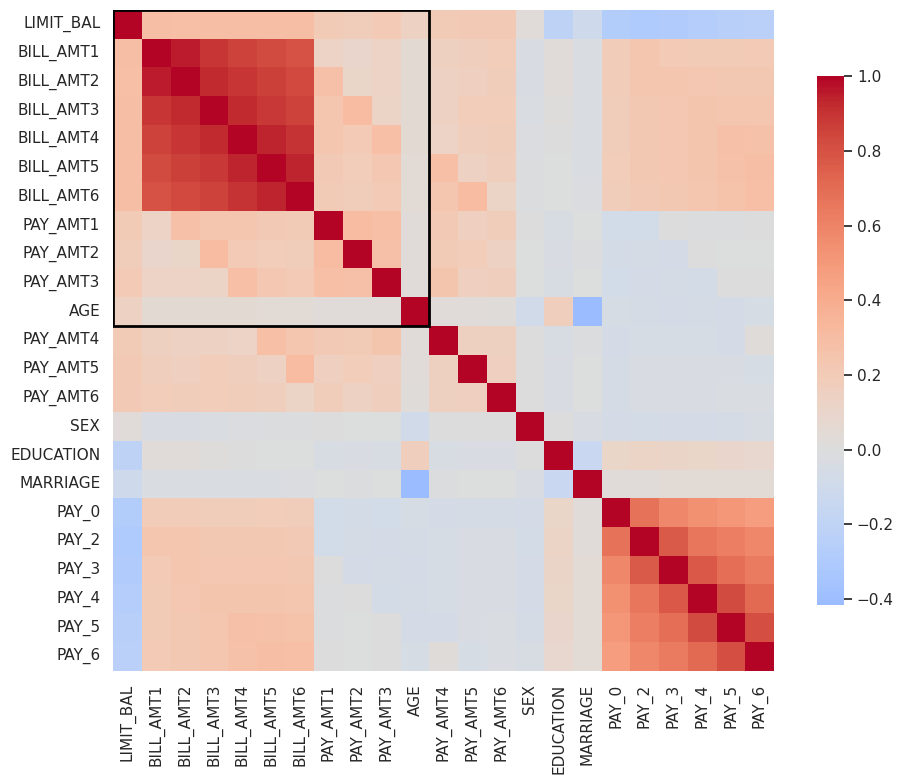

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

corr_matrix = X_train.corr(method="pearson")

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

# ---- draw black box around first 11 features ----
n = 11
rect = Rectangle(
    (0, 0),      # (x, y) bottom-left corner in heatmap coordinates
    n,           # width
    n,           # height
    fill=False,
    edgecolor="black",
    linewidth=2
)
ax.add_patch(rect)

plt.title("")
plt.tight_layout()
plt.show()


In [6]:
corr_matrix

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,...,PAY_AMT6,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
LIMIT_BAL,1.000000,0.288832,0.282435,0.288113,0.295995,0.296345,0.290686,0.194235,0.181045,0.207570,...,0.217846,0.028022,-0.214519,-0.109719,-0.271095,-0.297687,-0.288861,-0.268228,-0.251208,-0.236368
BILL_AMT1,0.288832,1.000000,0.951242,0.890434,0.855566,0.827060,0.798025,0.132454,0.097969,0.132236,...,0.183857,-0.032077,0.027735,-0.024688,0.189238,0.235579,0.208796,0.204261,0.203961,0.205984
BILL_AMT2,0.282435,0.951242,1.000000,0.927946,0.890173,0.860225,0.828870,0.276409,0.105668,0.129731,...,0.179857,-0.030643,0.022589,-0.022858,0.191367,0.235200,0.237064,0.227644,0.225161,0.226497
BILL_AMT3,0.288113,0.890434,0.927946,1.000000,0.924853,0.887718,0.854531,0.241382,0.313296,0.123365,...,0.184988,-0.024241,0.015432,-0.027257,0.180611,0.223216,0.227478,0.247189,0.242410,0.241377
BILL_AMT4,0.295995,0.855566,0.890173,0.924853,1.000000,0.940747,0.899956,0.232473,0.209956,0.283419,...,0.180230,-0.018485,0.002845,-0.024448,0.180650,0.222948,0.227870,0.248573,0.272069,0.266811
BILL_AMT5,0.296345,0.827060,0.860225,0.887718,0.940747,1.000000,0.943950,0.218598,0.182705,0.227102,...,0.170255,-0.013981,-0.004548,-0.024909,0.183064,0.222505,0.227021,0.246684,0.270423,0.291345
BILL_AMT6,0.290686,0.798025,0.828870,0.854531,0.899956,0.943950,1.000000,0.202535,0.175237,0.209669,...,0.125131,-0.012874,-0.005216,-0.020164,0.178130,0.220147,0.224440,0.243108,0.263094,0.285663
PAY_AMT1,0.194235,0.132454,0.276409,0.241382,0.232473,0.218598,0.202535,1.000000,0.308309,0.285305,...,0.178488,0.001095,-0.039210,-0.002977,-0.080524,-0.081957,0.001189,-0.010174,-0.005620,0.000813
PAY_AMT2,0.181045,0.097969,0.105668,0.313296,0.209956,0.182705,0.175237,0.308309,1.000000,0.280920,...,0.142371,-0.002437,-0.032749,-0.005495,-0.071048,-0.060461,-0.064779,0.000822,-0.001548,-0.004330
PAY_AMT3,0.207570,0.132236,0.129731,0.123365,0.283419,0.227102,0.209669,0.285305,0.280920,1.000000,...,0.167987,-0.004972,-0.042739,-0.001912,-0.079914,-0.063240,-0.057989,-0.072327,0.006664,0.004419


Syn2 correlations

In [12]:
a = corr_matrix.iloc[1:7,1:7]
a

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.000000,0.951242,0.890434,0.855566,0.827060,0.798025
BILL_AMT2,0.951242,1.000000,0.927946,0.890173,0.860225,0.828870
BILL_AMT3,0.890434,0.927946,1.000000,0.924853,0.887718,0.854531
BILL_AMT4,0.855566,0.890173,0.924853,1.000000,0.940747,0.899956
BILL_AMT5,0.827060,0.860225,0.887718,0.940747,1.000000,0.943950
BILL_AMT6,0.798025,0.828870,0.854531,0.899956,0.943950,1.000000


In [29]:
corr = a.values
upper = np.triu_indices_from(corr, k=1)
vals = corr[upper]
avg_corr = vals.mean()
print(avg_corr)

0.8854197328242667
